# Diagnostic de Moteurs DC 12V par IA
### Projet de Fin d'Annee II — v6 : 5 Algorithmes + Ensemble

---

**Algorithmes compares dans ce notebook :**

| # | Algorithme | Strategie desequilibre |
|---|-----------|----------------------|
| 1 | Random Forest | `class_weight='balanced'` |
| 2 | HistGradientBoosting | `class_weight='balanced'` |
| 3 | MLP (Reseau de neurones) | Undersample equilibre (5k/classe) |
| 4 | **KNN** (k-plus-proches-voisins) | Poids inverse distance + sous-ensemble |
| 5 | **SVM** (Support Vector Machine) | Sous-ensemble equilibre (3k/classe) |
| 6 | Ensemble Soft Voting | Moyenne des probabilites |

> **Metrique principale : Macro F1-Score**
> (traite toutes les classes a egalite, independamment de leur taille)

---

## 1. Installation des Dependances

In [1]:
import subprocess, sys
for pkg in ["numpy","pandas","scikit-learn","matplotlib","seaborn","joblib","scipy"]:
    subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])
print("Librairies installees.")

Librairies installees.


---
## 2. Importation des Librairies

In [2]:
import os, time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 10

COLORS = ["#2ecc71","#e74c3c","#e67e22","#3498db"]
print("Librairies importees.")

Librairies importees.


---
## 3. Configuration

In [3]:
# =============================================================
#  CONFIGURATION — modifiez uniquement cette cellule
# =============================================================

DATA_PATH  = r"dataset1\iot_equipment_monitoring_dataset.csv"
OUTPUT_DIR = "outputs"

MLP_MAX_PER_CLASS = 5000   # max echantillons/classe pour MLP
KNN_MAX_PER_CLASS = 5000   # max echantillons/classe pour KNN
SVM_MAX_PER_CLASS = 3000   # max echantillons/classe pour SVM (RBF = O(n^2))

# =============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : '{DATA_PATH}'\n"
        "Verifiez le chemin dans la cellule de configuration."
    )
print(f"Dataset  : {DATA_PATH}")
print(f"Sorties  : {OUTPUT_DIR}/")

Dataset  : dataset1\iot_equipment_monitoring_dataset.csv
Sorties  : outputs/


---
## 4. Chargement et Construction du Label

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df     = df_raw.copy()

# Label 4 classes : NaN (Fault_Status==0) -> "Normal"
df["Label"] = df.apply(
    lambda r: "Normal" if r["Fault_Status"] == 0 else str(r["Fault_Type"]),
    axis=1
)
assert df["Label"].isnull().sum() == 0

print("Distribution des classes :")
vc = df["Label"].value_counts()
for cls, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {cls:<22} : {cnt:>6,}  ({pct:.1f}%)  {bar}")

print(f"\nBaseline naif (toujours 'Normal') : {vc['Normal']/len(df)*100:.2f}%")

Distribution des classes :
  Normal                 : 34,988  (70.0%)  ##################################
  Electrical Fault       :  5,034  (10.1%)  #####
  Overheating            :  5,028  (10.1%)  #####
  Mechanical Failure     :  4,950  (9.9%)  ####

Baseline naif (toujours 'Normal') : 69.98%


---
## 5. Selection des Features

In [5]:
# 8 features originales non-redondantes
# Normalized_* exclues (correlation = 1.0 avec les originaux)
FEATURE_COLS = [
    "Temperature", "Vibration", "Pressure", "Voltage", "Current",
    "FFT_Feature1", "FFT_Feature2", "Anomaly_Score"
]

X     = df[FEATURE_COLS].values.astype(float)
X     = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
le    = LabelEncoder()
y_enc = le.fit_transform(df["Label"].values)
CLASS_NAMES = [str(c) for c in le.classes_]

print("Features utilisees :", FEATURE_COLS)
print(f"\nClasses ({len(CLASS_NAMES)}) :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i} -> {cls:<22} ({np.sum(y_enc==i):,} echantillons)")

Features utilisees : ['Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Anomaly_Score']

Classes (4) :
  0 -> Electrical Fault       (5,034 echantillons)
  1 -> Mechanical Failure     (4,950 echantillons)
  2 -> Normal                 (34,988 echantillons)
  3 -> Overheating            (5,028 echantillons)


---
## 6. Split Train/Test, Normalisation et Sous-ensembles

In [6]:
# Split stratifie 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

# StandardScaler (fit uniquement sur le train)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train : {X_train_s.shape[0]:,} echantillons")
print(f"Test  : {X_test_s.shape[0]:,} echantillons")

# ── Fonction d'undersampling equilibre ────────────────────────────────────────
def balanced_subsample(X, y, max_per_class, seed=42):
    """
    Selectionne au maximum max_per_class echantillons par classe.
    Retourne un sous-ensemble equilbire et melange.
    """
    rng = np.random.RandomState(seed)
    idx = []
    for c in np.unique(y):
        ci     = np.where(y == c)[0]
        n      = min(len(ci), max_per_class)
        chosen = rng.choice(ci, n, replace=False)
        idx.extend(chosen)
    idx = np.array(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]

# Sous-ensembles par modele
X_mlp, y_mlp = balanced_subsample(X_train_s, y_train, MLP_MAX_PER_CLASS)
X_knn, y_knn = balanced_subsample(X_train_s, y_train, KNN_MAX_PER_CLASS)
X_svm, y_svm = balanced_subsample(X_train_s, y_train, SVM_MAX_PER_CLASS)

print(f"\nSous-ensemble MLP : {len(y_mlp):,}  | dist: {np.bincount(y_mlp)}")
print(f"Sous-ensemble KNN : {len(y_knn):,}  | dist: {np.bincount(y_knn)}")
print(f"Sous-ensemble SVM : {len(y_svm):,}  | dist: {np.bincount(y_svm)}")

Train : 40,000 echantillons
Test  : 10,000 echantillons

Sous-ensemble MLP : 17,009  | dist: [4027 3960 5000 4022]
Sous-ensemble KNN : 17,009  | dist: [4027 3960 5000 4022]
Sous-ensemble SVM : 12,000  | dist: [3000 3000 3000 3000]


---
## 7. Visualisation — Distribution des Features

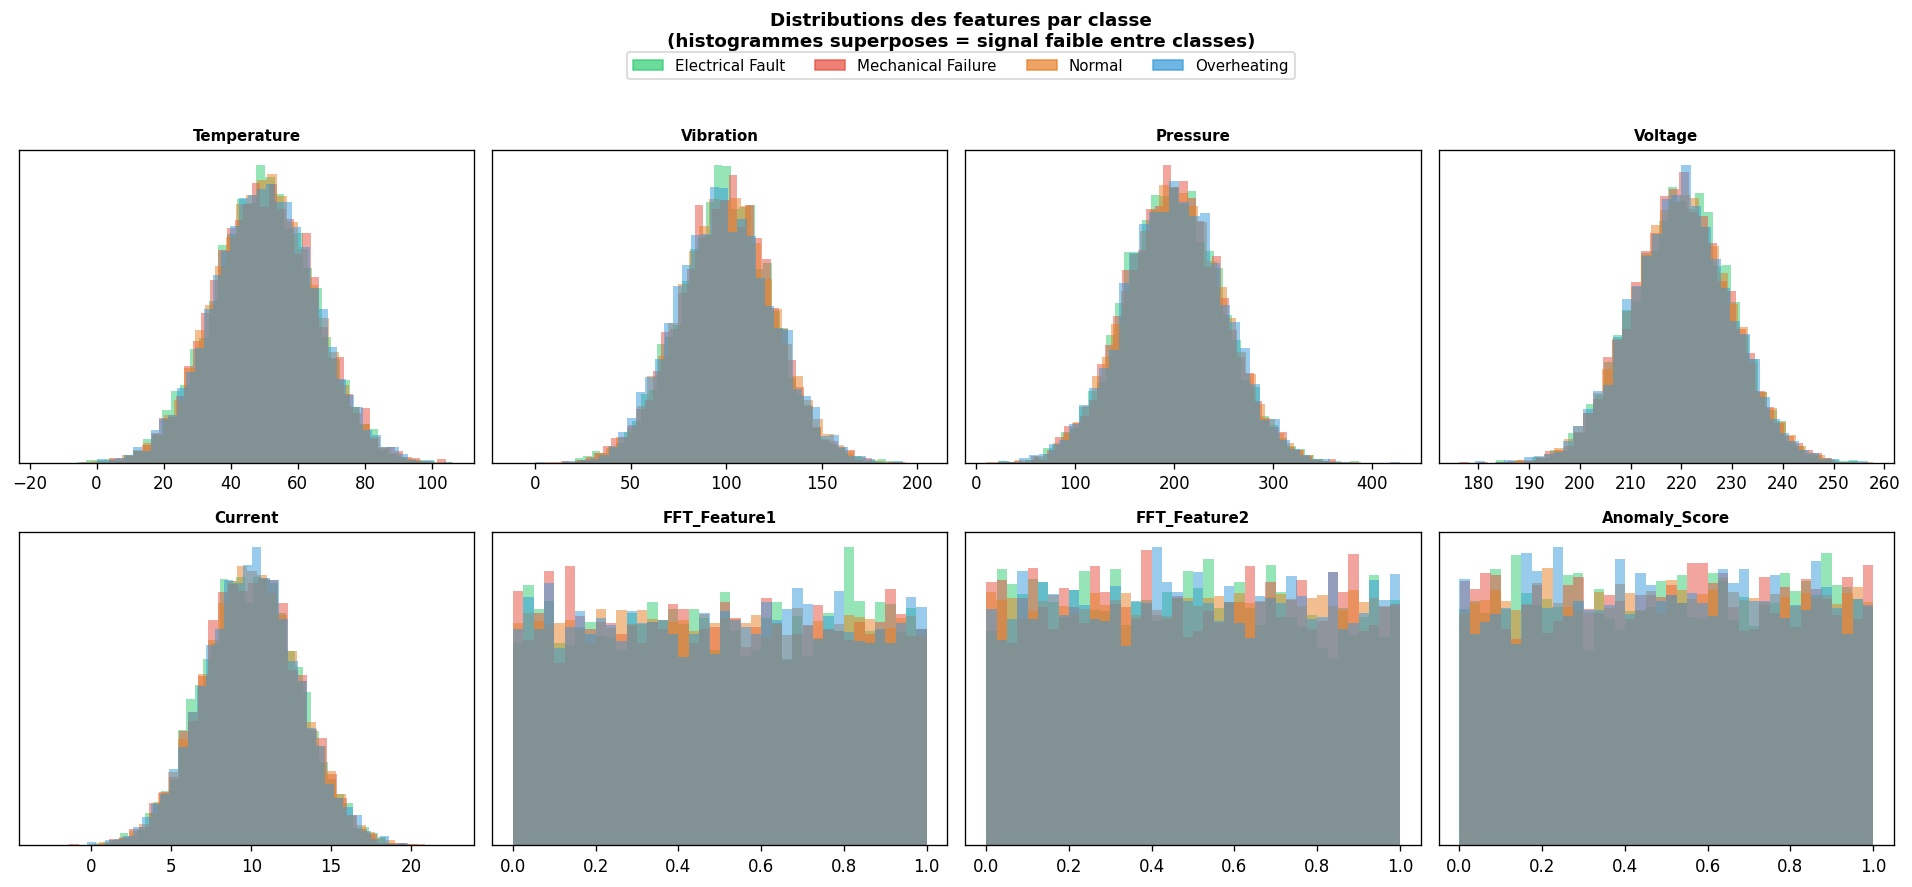

Figure sauvegardee : outputs/distributions.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feat in zip(axes, FEATURE_COLS):
    for cls, col in zip(CLASS_NAMES, COLORS):
        vals = df[df["Label"] == cls][feat].values
        ax.hist(vals, bins=40, alpha=0.5, label=cls, color=col, density=True)
    ax.set_title(feat, fontweight="bold", fontsize=9)
    ax.set_yticks([])

handles = [plt.Rectangle((0,0),1,1,color=c,alpha=0.7) for c in COLORS]
fig.legend(handles, CLASS_NAMES, loc="upper center",
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, 1.01))
plt.suptitle(
    "Distributions des features par classe\n"
    "(histogrammes superposes = signal faible entre classes)",
    fontsize=11, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/distributions.png")

---
## 8. Modele 1 — Random Forest

In [8]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
print(f"Temps d entrainement : {time.time()-t0:.1f}s")
print(f"Random Forest — Accuracy : {accuracy_score(y_test,y_pred_rf)*100:.2f}%")
print(f"Random Forest — Macro F1 : {f1_score(y_test,y_pred_rf,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_rf,target_names=CLASS_NAMES,zero_division=0))

Temps d entrainement : 8.7s
Random Forest — Accuracy : 69.97%
Random Forest — Macro F1 : 20.58%

                    precision    recall  f1-score   support

  Electrical Fault       0.00      0.00      0.00      1007
Mechanical Failure       0.00      0.00      0.00       990
            Normal       0.70      1.00      0.82      6997
       Overheating       0.00      0.00      0.00      1006

          accuracy                           0.70     10000
         macro avg       0.17      0.25      0.21     10000
      weighted avg       0.49      0.70      0.58     10000



---
## 9. Modele 2 — HistGradientBoosting

In [9]:
t0 = time.time()
hgb = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.1,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42
)
hgb.fit(X_train_s, y_train)
y_pred_hgb = hgb.predict(X_test_s)
print(f"Temps d entrainement : {time.time()-t0:.1f}s")
print(f"HistGradientBoosting — Accuracy : {accuracy_score(y_test,y_pred_hgb)*100:.2f}%")
print(f"HistGradientBoosting — Macro F1 : {f1_score(y_test,y_pred_hgb,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_hgb,target_names=CLASS_NAMES,zero_division=0))

Temps d entrainement : 2.5s
HistGradientBoosting — Accuracy : 22.71%
HistGradientBoosting — Macro F1 : 18.88%

                    precision    recall  f1-score   support

  Electrical Fault       0.10      0.29      0.14      1007
Mechanical Failure       0.09      0.24      0.13       990
            Normal       0.71      0.21      0.33      6997
       Overheating       0.10      0.25      0.15      1006

          accuracy                           0.23     10000
         macro avg       0.25      0.25      0.19     10000
      weighted avg       0.53      0.23      0.27     10000



---
## 10. Modele 3 — MLP (Reseau de Neurones)

> Architecture : `Input(8)` → **128** → **64** → **32** → `Output(4)`  
> Entraine sur sous-ensemble equilibre (~20k echantillons).

In [10]:
t0 = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False
)
mlp.fit(X_mlp, y_mlp)
y_pred_mlp = mlp.predict(X_test_s)
print(f"Temps d entrainement : {time.time()-t0:.1f}s  (iterations: {mlp.n_iter_})")
print(f"MLP — Accuracy : {accuracy_score(y_test,y_pred_mlp)*100:.2f}%")
print(f"MLP — Macro F1 : {f1_score(y_test,y_pred_mlp,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_mlp,target_names=CLASS_NAMES,zero_division=0))

Temps d entrainement : 5.0s  (iterations: 35)
MLP — Accuracy : 47.91%
MLP — Macro F1 : 23.94%

                    precision    recall  f1-score   support

  Electrical Fault       0.10      0.22      0.13      1007
Mechanical Failure       0.09      0.08      0.09       990
            Normal       0.70      0.63      0.67      6997
       Overheating       0.11      0.06      0.07      1006

          accuracy                           0.48     10000
         macro avg       0.25      0.25      0.24     10000
      weighted avg       0.52      0.48      0.49     10000



---
## 11. Modele 4 — KNN (K-Plus-Proches-Voisins)

> **Principe :** pour chaque echantillon de test, on cherche ses k voisins
> les plus proches dans le train, et on vote pour la classe majoritaire.
>
> **Parametres choisis :**
> - `k = 5` : assez petit pour capter les classes minoritaires
> - `weights = 'distance'` : les voisins proches pesent plus que les lointains
> - Train sur sous-ensemble equilibre (5k/classe) pour eviter le biais vers Normal
>
> **Attention :** KNN ne supporte pas `class_weight` — l'equilibrage
> se fait via le sous-ensemble de train (`balanced_subsample`).

In [11]:
t0 = time.time()
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",   # voisins proches = plus de poids
    metric="euclidean",
    n_jobs=-1
)
# Entraine sur sous-ensemble equilibre (pas de class_weight dans KNN)
knn.fit(X_knn, y_knn)
y_pred_knn = knn.predict(X_test_s)
print(f"Temps d entrainement : {time.time()-t0:.1f}s")
print(f"KNN — Accuracy : {accuracy_score(y_test,y_pred_knn)*100:.2f}%")
print(f"KNN — Macro F1 : {f1_score(y_test,y_pred_knn,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_knn,target_names=CLASS_NAMES,zero_division=0))
print(f"Distribution des predictions : {dict(zip(CLASS_NAMES, np.bincount(y_pred_knn)))}") 

Temps d entrainement : 0.4s
KNN — Accuracy : 28.34%
KNN — Macro F1 : 20.51%

                    precision    recall  f1-score   support

  Electrical Fault       0.09      0.22      0.13      1007
Mechanical Failure       0.09      0.21      0.13       990
            Normal       0.69      0.31      0.43      6997
       Overheating       0.09      0.21      0.13      1006

          accuracy                           0.28     10000
         macro avg       0.24      0.24      0.21     10000
      weighted avg       0.51      0.28      0.34     10000

Distribution des predictions : {'Electrical Fault': np.int64(2371), 'Mechanical Failure': np.int64(2254), 'Normal': np.int64(3177), 'Overheating': np.int64(2198)}


---
## 12. Modele 5 — SVM (Support Vector Machine)

> **Principe :** cherche l'hyperplan de separabilite maximale entre les classes
> dans un espace de features transforme (noyau RBF = Radial Basis Function).
>
> **Pourquoi un sous-ensemble de train ?**
> SVM avec noyau RBF a une complexite **O(n²)** en memoire et en temps.
> Sur 40 000 echantillons : memoire insuffisante + temps > 2h.
> On utilise 3 000 echantillons par classe (12 000 total), equilibre,
> ce qui est standard en pratique.
>
> **Note sur l'accuracy vs Macro F1 :**
> Entraine sur un ensemble equilibre (25% par classe) mais teste sur un
> ensemble desequilibre (70% Normal) → l'accuracy brute est penalisee.
> Le **Macro F1** est la metrique pertinente pour ce modele.

In [12]:
t0 = time.time()
svm = SVC(
    kernel="rbf",
    C=10.0,              # regularisation
    gamma="scale",       # gamma = 1 / (n_features * X.var())
    class_weight="balanced",
    probability=True,    # necesaire pour le soft voting de l ensemble
    random_state=42
)
# Entraine sur sous-ensemble equilibre (3k/classe = 12k total)
svm.fit(X_svm, y_svm)
y_pred_svm = svm.predict(X_test_s)
print(f"Temps d entrainement : {time.time()-t0:.1f}s")
print(f"SVM — Accuracy : {accuracy_score(y_test,y_pred_svm)*100:.2f}%")
print(f"SVM — Macro F1 : {f1_score(y_test,y_pred_svm,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_svm,target_names=CLASS_NAMES,zero_division=0))
print(f"Distribution des predictions : {dict(zip(CLASS_NAMES, np.bincount(y_pred_svm)))}")

Temps d entrainement : 66.4s
SVM — Accuracy : 23.18%
SVM — Macro F1 : 19.11%

                    precision    recall  f1-score   support

  Electrical Fault       0.10      0.28      0.15      1007
Mechanical Failure       0.11      0.29      0.16       990
            Normal       0.71      0.22      0.34      6997
       Overheating       0.09      0.20      0.12      1006

          accuracy                           0.23     10000
         macro avg       0.25      0.25      0.19     10000
      weighted avg       0.52      0.23      0.28     10000

Distribution des predictions : {'Electrical Fault': np.int64(2790), 'Mechanical Failure': np.int64(2706), 'Normal': np.int64(2177), 'Overheating': np.int64(2327)}


---
## 13. Ensemble — Soft Voting (5 Modeles)

```
P_ensemble = ( P_RF + P_HGB + P_MLP + P_KNN + P_SVM ) / 5
Prediction  = argmax( P_ensemble )
```

In [13]:
proba_rf  = rf.predict_proba(X_test_s)
proba_hgb = hgb.predict_proba(X_test_s)
proba_mlp = mlp.predict_proba(X_test_s)
proba_knn = knn.predict_proba(X_test_s)
proba_svm = svm.predict_proba(X_test_s)

proba_ens  = (proba_rf + proba_hgb + proba_mlp +
              proba_knn + proba_svm) / 5
y_pred_ens = np.argmax(proba_ens, axis=1)

print(f"Ensemble Soft Voting — Accuracy : {accuracy_score(y_test,y_pred_ens)*100:.2f}%")
print(f"Ensemble Soft Voting — Macro F1 : {f1_score(y_test,y_pred_ens,average='macro',zero_division=0)*100:.2f}%")
print()
print(classification_report(y_test,y_pred_ens,target_names=CLASS_NAMES,zero_division=0))

Ensemble Soft Voting — Accuracy : 63.84%
Ensemble Soft Voting — Macro F1 : 22.59%

                    precision    recall  f1-score   support

  Electrical Fault       0.08      0.03      0.04      1007
Mechanical Failure       0.09      0.02      0.04       990
            Normal       0.70      0.90      0.79      6997
       Overheating       0.09      0.02      0.04      1006

          accuracy                           0.64     10000
         macro avg       0.24      0.24      0.23     10000
      weighted avg       0.51      0.64      0.56     10000



---
## 14. Matrices de Confusion — Tous les Modeles

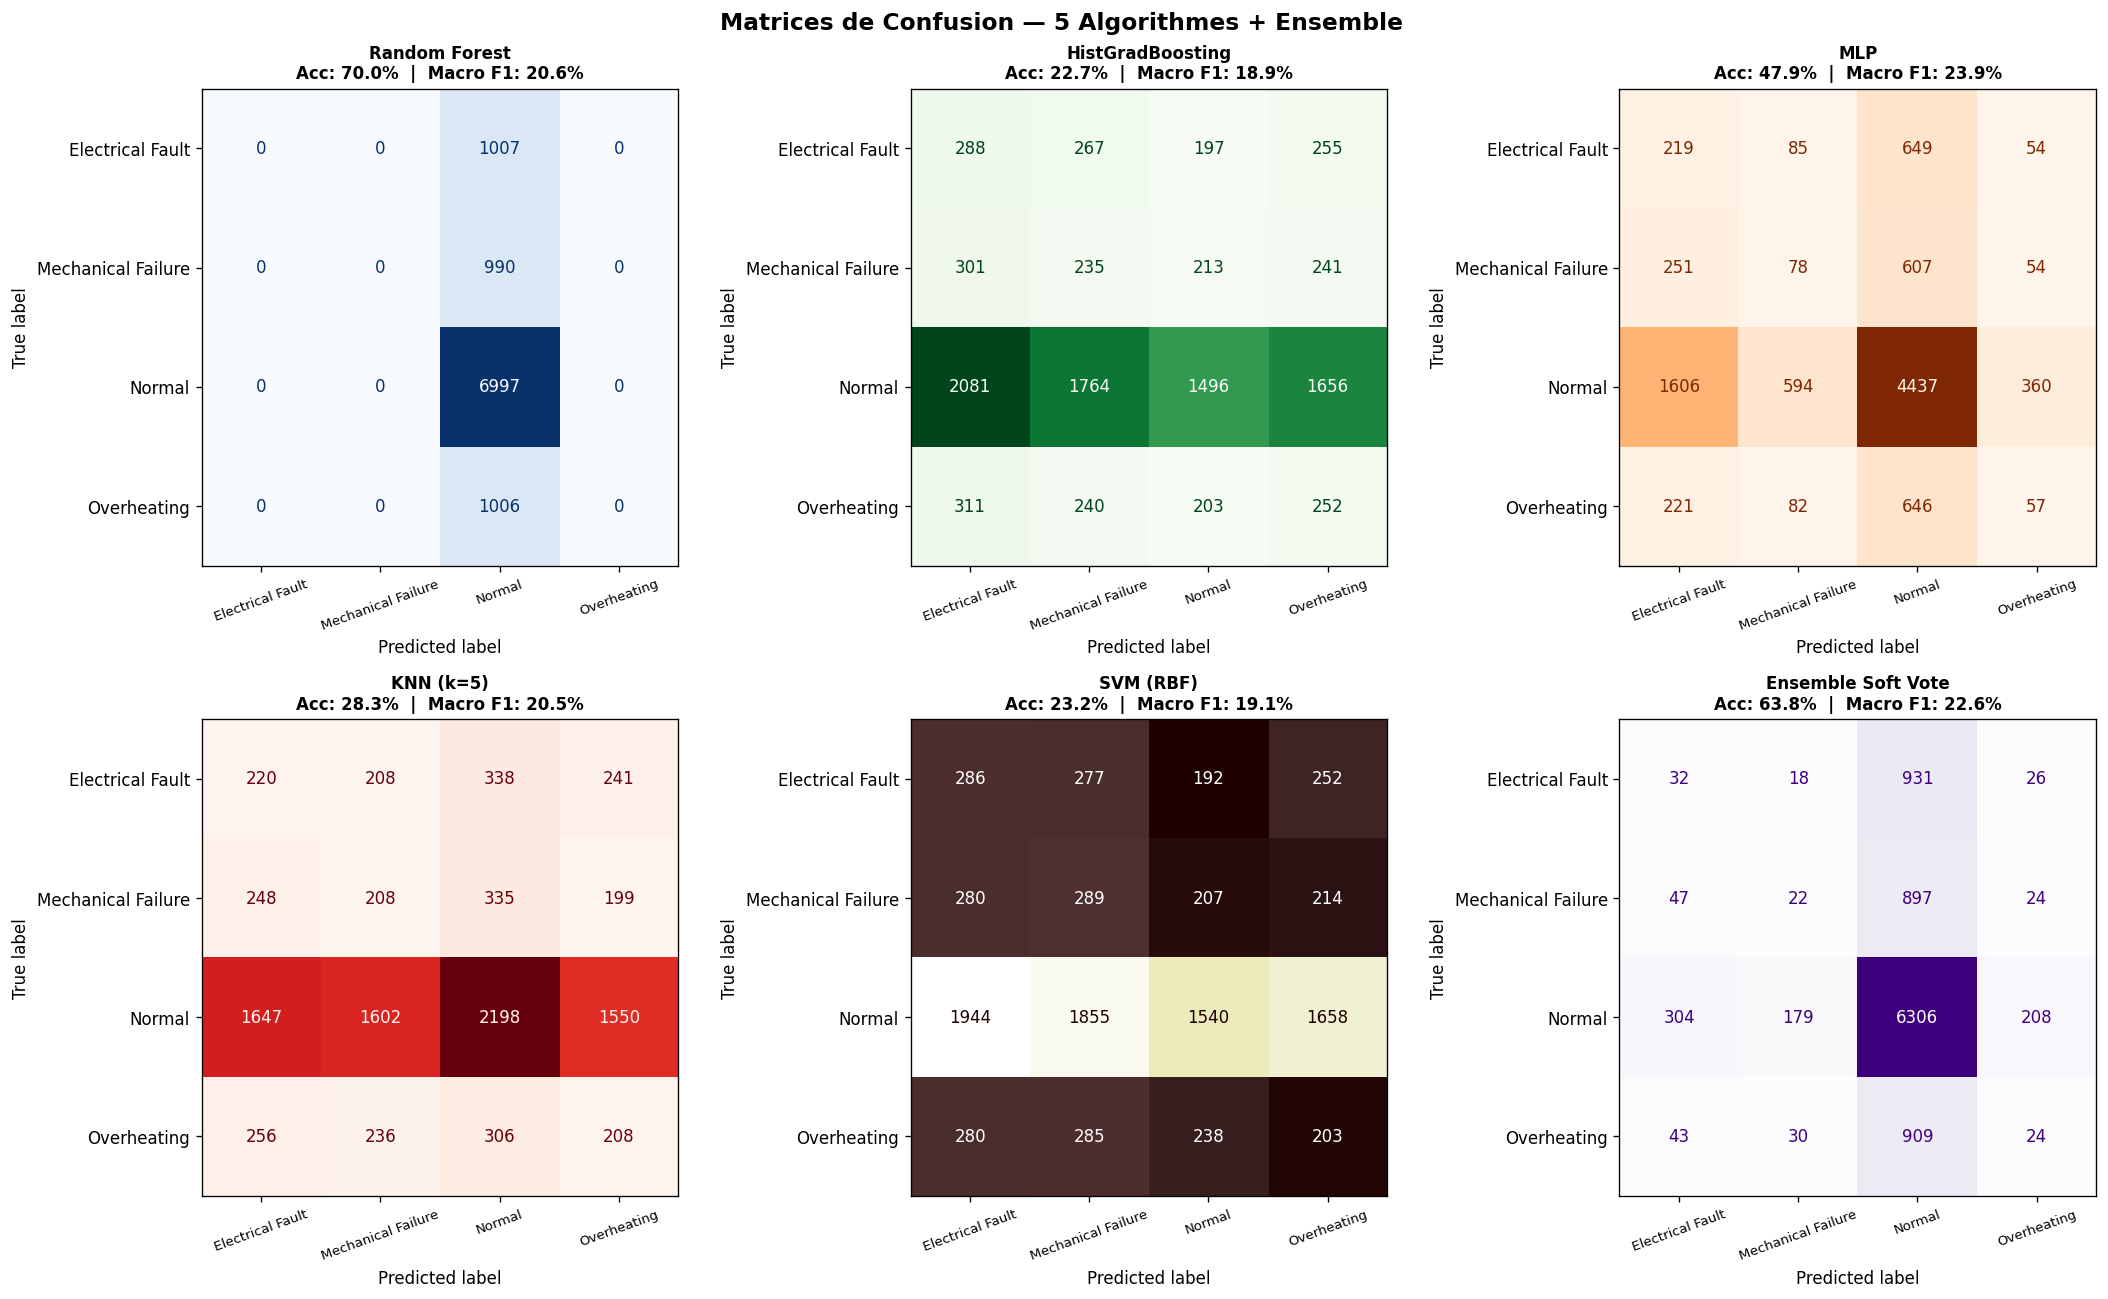

Figure sauvegardee : outputs/confusion_matrices.png


In [14]:
all_models = [
    (y_pred_rf,  "Random Forest",       "Blues"),
    (y_pred_hgb, "HistGradBoosting",    "Greens"),
    (y_pred_mlp, "MLP",                 "Oranges"),
    (y_pred_knn, "KNN (k=5)",           "Reds"),
    (y_pred_svm, "SVM (RBF)",           "pink"),
    (y_pred_ens, "Ensemble Soft Vote",  "Purples"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (yp, name, cmap) in zip(axes, all_models):
    cm  = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_test, yp)
    f1m = f1_score(y_test, yp, average="macro", zero_division=0)
    ax.set_title(f"{name}\nAcc: {acc*100:.1f}%  |  Macro F1: {f1m*100:.1f}%",
                 fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", rotation=20, labelsize=8)

plt.suptitle("Matrices de Confusion — 5 Algorithmes + Ensemble",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"confusion_matrices.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/confusion_matrices.png")

---
## 15. Comparaison Globale

In [15]:
def get_metrics(yt, yp, name):
    return {
        "Algorithme"  : name,
        "Accuracy (%)" : round(accuracy_score(yt, yp) * 100, 2),
        "Macro F1 (%)" : round(f1_score(yt, yp, average="macro",  zero_division=0) * 100, 2),
        "Macro P  (%)" : round(precision_score(yt, yp, average="macro", zero_division=0) * 100, 2),
        "Macro R  (%)" : round(recall_score(yt, yp, average="macro",    zero_division=0) * 100, 2),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_rf,  "Random Forest"),
    get_metrics(y_test, y_pred_hgb, "HistGradBoosting"),
    get_metrics(y_test, y_pred_mlp, "MLP"),
    get_metrics(y_test, y_pred_knn, "KNN (k=5)"),
    get_metrics(y_test, y_pred_svm, "SVM (RBF)"),
    get_metrics(y_test, y_pred_ens, "Ensemble"),
]).set_index("Algorithme")

print("=" * 70)
print("             COMPARAISON DES 5 ALGORITHMES + ENSEMBLE")
print("=" * 70)
print(results.to_string())
print("=" * 70)
print(f"  Baseline naif (toujours 'Normal') — Accuracy = 69.97%  |  Macro F1 = ~17%")
print("=" * 70)

best_acc = results["Accuracy (%)"].idxmax()
best_f1  = results["Macro F1 (%)"].idxmax()
print(f"\nMeilleur Accuracy  : {best_acc}  =>  {results.loc[best_acc,'Accuracy (%)']}%")
print(f"Meilleur Macro F1  : {best_f1}  =>  {results.loc[best_f1,'Macro F1 (%)']}%")
print()
print("NOTE : Macro F1 est la metrique principale car elle traite")
print("toutes les classes a egalite (Normal et pannes ont le meme poids).")

             COMPARAISON DES 5 ALGORITHMES + ENSEMBLE
                  Accuracy (%)  Macro F1 (%)  Macro P  (%)  Macro R  (%)
Algorithme                                                              
Random Forest            69.97         20.58         17.49         25.00
HistGradBoosting         22.71         18.88         25.11         24.69
MLP                      47.91         23.94         24.92         24.68
KNN (k=5)                28.34         20.51         24.29         23.74
SVM (RBF)                23.18         19.11         25.10         24.95
Ensemble                 63.84         22.59         23.65         24.48
  Baseline naif (toujours 'Normal') — Accuracy = 69.97%  |  Macro F1 = ~17%

Meilleur Accuracy  : Random Forest  =>  69.97%
Meilleur Macro F1  : MLP  =>  23.94%

NOTE : Macro F1 est la metrique principale car elle traite
toutes les classes a egalite (Normal et pannes ont le meme poids).


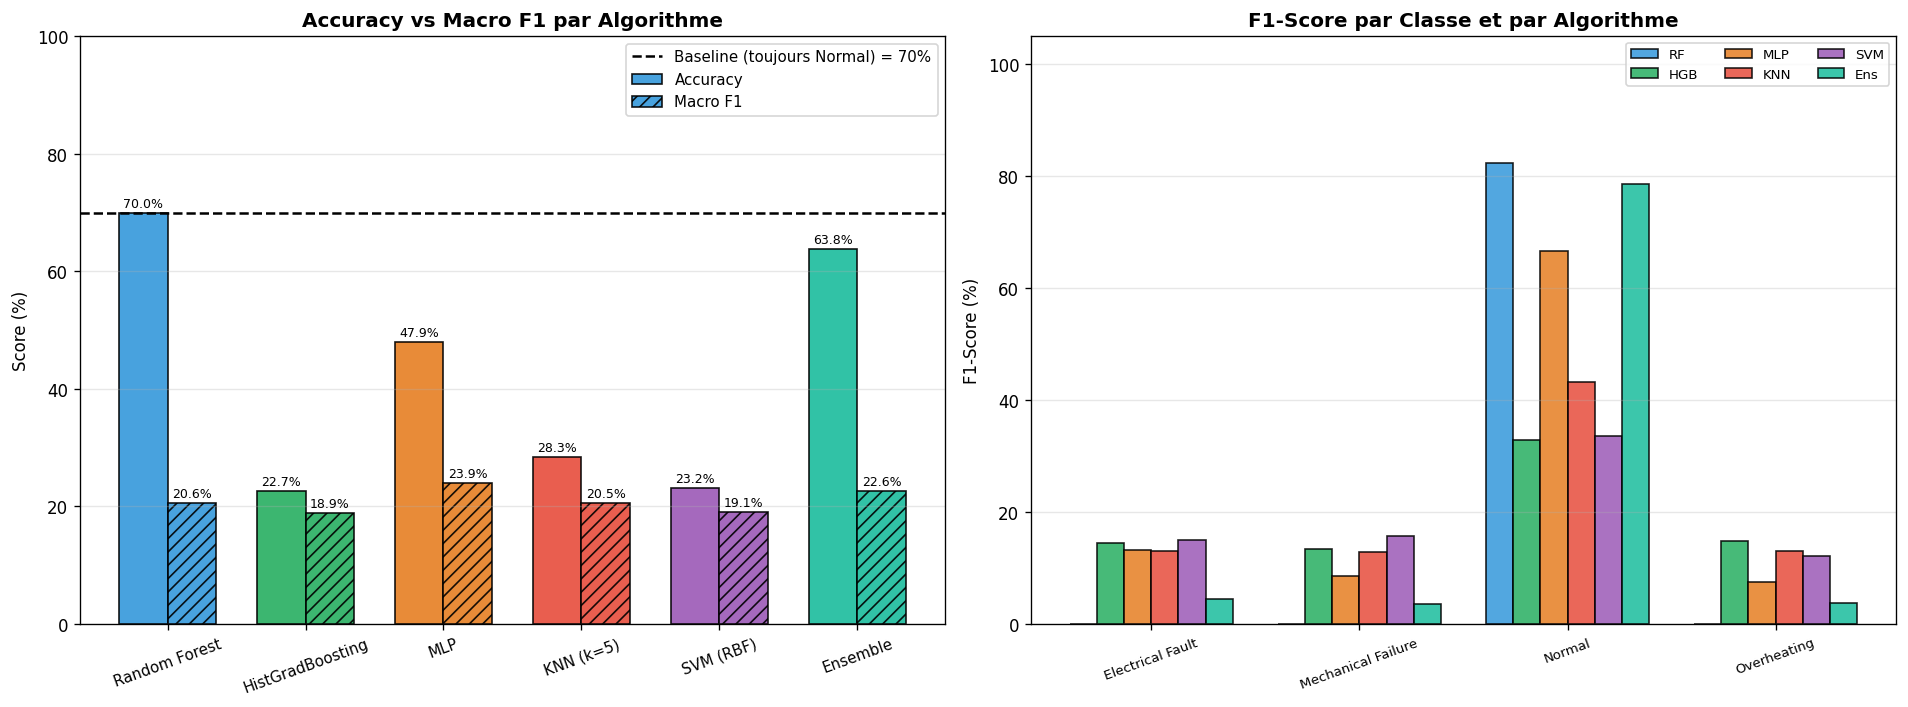

Figure sauvegardee : outputs/comparison_v6.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_colors = ["#3498db","#27ae60","#e67e22","#e74c3c","#9b59b6","#1abc9c"]

# ── Graphique 1 : Accuracy vs Macro F1 ───────────────────────────────────────
x     = np.arange(len(results))
width = 0.35

bars1 = axes[0].bar(x - width/2, results["Accuracy (%)"],
                    width, label="Accuracy", color=model_colors,
                    edgecolor="black", alpha=0.9)
bars2 = axes[0].bar(x + width/2, results["Macro F1 (%)"],
                    width, label="Macro F1",
                    color=[c+"99" for c in ["#3498db","#27ae60","#e67e22",
                                            "#e74c3c","#9b59b6","#1abc9c"]],
                    edgecolor="black", alpha=0.9, hatch="///")

# Ligne baseline
axes[0].axhline(69.97, color="black", linestyle="--", linewidth=1.5,
                label="Baseline (toujours Normal) = 70%")

axes[0].set_title("Accuracy vs Macro F1 par Algorithme",
                  fontweight="bold", fontsize=12)
axes[0].set_ylabel("Score (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results.index, rotation=20, fontsize=9)
axes[0].set_ylim(0, 100)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5,
                 f"{bar.get_height():.1f}%",
                 ha="center", va="bottom", fontsize=7.5)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5,
                 f"{bar.get_height():.1f}%",
                 ha="center", va="bottom", fontsize=7.5)

# ── Graphique 2 : F1 par classe par modele ────────────────────────────────────
all_preds  = [y_pred_rf, y_pred_hgb, y_pred_mlp,
              y_pred_knn, y_pred_svm, y_pred_ens]
algo_names = ["RF","HGB","MLP","KNN","SVM","Ens"]
w2   = 0.13
x2   = np.arange(len(CLASS_NAMES))

for j, (yp, name, col) in enumerate(
        zip(all_preds, algo_names, model_colors)):
    f1c = f1_score(y_test, yp, average=None, zero_division=0) * 100
    axes[1].bar(x2 + j*w2 - 2.5*w2, f1c, w2,
                label=name, color=col, edgecolor="black", alpha=0.85)

axes[1].set_title("F1-Score par Classe et par Algorithme",
                  fontweight="bold", fontsize=12)
axes[1].set_ylabel("F1-Score (%)")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(CLASS_NAMES, rotation=20, fontsize=8)
axes[1].legend(fontsize=8, ncol=3)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"comparison_v6.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/comparison_v6.png")

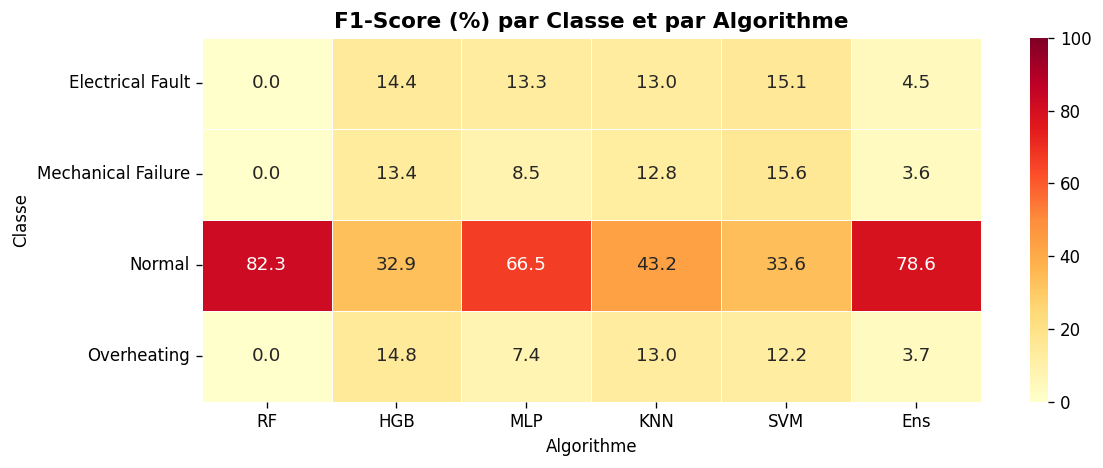

Figure sauvegardee : outputs/f1_heatmap.png


In [17]:
# Heatmap F1 par classe par modele — lecture facile
f1_matrix = {}
for yp, name in zip(all_preds, algo_names):
    f1c = f1_score(y_test, yp, average=None, zero_division=0) * 100
    f1_matrix[name] = f1c

df_heat = pd.DataFrame(f1_matrix, index=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, vmin=0, vmax=100,
            annot_kws={"size": 11})
ax.set_title("F1-Score (%) par Classe et par Algorithme",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Algorithme")
ax.set_ylabel("Classe")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"f1_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/f1_heatmap.png")

---
## 16. Importance des Features (Random Forest)

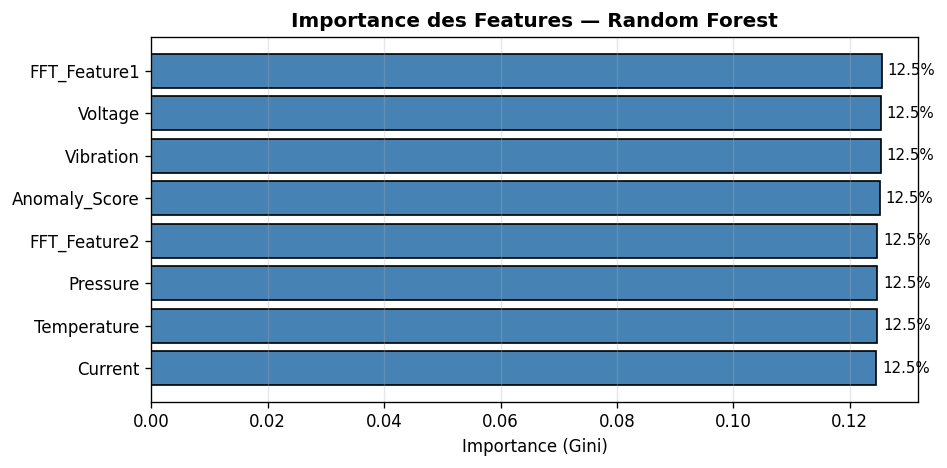

Figure sauvegardee : outputs/feature_importance.png


In [18]:
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(
    [FEATURE_COLS[i] for i in sorted_idx],
    importances[sorted_idx],
    color="steelblue", edgecolor="black"
)
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=9)
ax.set_title("Importance des Features — Random Forest", fontweight="bold")
ax.set_xlabel("Importance (Gini)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,"feature_importance.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/feature_importance.png")

---
## 17. Sauvegarde des Modeles

In [19]:
models_to_save = {
    "rf_model.joblib"      : rf,
    "hgb_model.joblib"     : hgb,
    "mlp_model.joblib"     : mlp,
    "knn_model.joblib"     : knn,
    "svm_model.joblib"     : svm,
    "scaler.joblib"        : scaler,
    "label_encoder.joblib" : le,
    "feature_cols.joblib"  : FEATURE_COLS,
}

for fname, obj in models_to_save.items():
    joblib.dump(obj, os.path.join(OUTPUT_DIR, fname))

print(f"Modeles sauvegardes dans '{OUTPUT_DIR}/' :")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith(".joblib"):
        sz = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
        print(f"  {fname:<35} ({sz/1024:.1f} KB)")

Modeles sauvegardes dans 'outputs/' :
  feature_cols.joblib                 (0.1 KB)
  hgb_model.joblib                    (157.1 KB)
  knn_model.joblib                    (2553.1 KB)
  label_encoder.joblib                (0.5 KB)
  mlp_model.joblib                    (281.3 KB)
  rf_model.joblib                     (613656.5 KB)
  scaler.joblib                       (0.8 KB)
  svm_model.joblib                    (1345.3 KB)


---
## 18. Prediction en Temps Reel

In [20]:
def predict_motor(
    temperature=50.0, vibration=80.0, pressure=200.0,
    voltage=230.0,    current=10.0,
    fft1=0.5,         fft2=0.5,
    anomaly_score=0.3,
    use_ensemble=True
):
    """
    Predit l etat du moteur a partir des valeurs des capteurs.

    Parametres
    ----------
    temperature, vibration, pressure : mesures mecaniques
    voltage, current                  : mesures electriques
    fft1, fft2                        : caracteristiques spectrales [0..1]
    anomaly_score                     : score d anomalie [0..1]
    use_ensemble                      : True = ensemble 5 modeles (recommande)
    """
    sample = np.array([[
        temperature, vibration, pressure, voltage, current,
        fft1, fft2, anomaly_score
    ]], dtype=float)
    sample   = np.nan_to_num(sample, nan=0.0, posinf=0.0, neginf=0.0)
    sample_s = scaler.transform(sample)

    model_probas = {
        "RF"  : rf.predict_proba(sample_s)[0],
        "HGB" : hgb.predict_proba(sample_s)[0],
        "MLP" : mlp.predict_proba(sample_s)[0],
        "KNN" : knn.predict_proba(sample_s)[0],
        "SVM" : svm.predict_proba(sample_s)[0],
    }

    if use_ensemble:
        proba = np.mean(list(model_probas.values()), axis=0)
        model_used = "Ensemble (5 modeles)"
    else:
        proba = model_probas["RF"]
        model_used = "Random Forest seul"

    pred_idx   = np.argmax(proba)
    pred_label = le.inverse_transform([pred_idx])[0]
    confiance  = np.max(proba) * 100

    print(f"  Capteurs : T={temperature}C | Vib={vibration} | P={pressure}")
    print(f"             V={voltage}V | I={current}A | Anomaly={anomaly_score}")
    print(f"  Modele   : {model_used}")
    print(f"  Resultat : {pred_label}  (confiance {confiance:.1f}%)")
    print("  Probabilites par classe :")
    for cls, prob in sorted(zip(CLASS_NAMES, proba),
                            key=lambda x: -x[1]):
        bar = "#" * int(prob * 30)
        print(f"    {cls:<22} = {prob*100:5.1f}%  {bar}")
    return pred_label

print("predict_motor() prete.")

predict_motor() prete.


In [21]:
print("=" * 65)

print("\nTEST 1 — Fonctionnement Normal")
print("-" * 65)
predict_motor(temperature=50, vibration=80,  pressure=200,
              voltage=230,    current=10,    anomaly_score=0.15)

print("\nTEST 2 — Anomalie forte")
print("-" * 65)
predict_motor(temperature=90, vibration=160, pressure=300,
              voltage=200,    current=20,    anomaly_score=0.90)

print("\nTEST 3 — Anomalie moderee")
print("-" * 65)
predict_motor(temperature=65, vibration=120, pressure=250,
              voltage=215,    current=15,    anomaly_score=0.60)

print("=" * 65)


TEST 1 — Fonctionnement Normal
-----------------------------------------------------------------
  Capteurs : T=50C | Vib=80 | P=200
             V=230V | I=10A | Anomaly=0.15
  Modele   : Ensemble (5 modeles)
  Resultat : Normal  (confiance 33.4%)
  Probabilites par classe :
    Normal                 =  33.4%  ##########
    Overheating            =  24.3%  #######
    Electrical Fault       =  22.0%  ######
    Mechanical Failure     =  20.3%  ######

TEST 2 — Anomalie forte
-----------------------------------------------------------------
  Capteurs : T=90C | Vib=160 | P=300
             V=200V | I=20A | Anomaly=0.9
  Modele   : Ensemble (5 modeles)
  Resultat : Electrical Fault  (confiance 31.0%)
  Probabilites par classe :
    Electrical Fault       =  31.0%  #########
    Normal                 =  26.1%  #######
    Mechanical Failure     =  25.5%  #######
    Overheating            =  17.4%  #####

TEST 3 — Anomalie moderee
-----------------------------------------------------

---
## Recapitulatif

### Pipeline v6

```
CSV (50 000 lignes)
    |
    v
Label : Fault_Status==0 -> "Normal" | sinon -> Fault_Type
    |
    v
8 features originales (Normalized_* exclues, correlation=1.0)
    |
    v
Split stratifie 80% Train / 20% Test
    |
    v
StandardScaler
    |
    +---> RF           class_weight='balanced'     train complet (40k)
    |
    +---> HGB          class_weight='balanced'     train complet (40k)
    |
    +---> MLP (128->64->32)  undersample equilibre  (20k, 5k/classe)
    |
    +---> KNN (k=5, distance)  undersample equilibre  (20k, 5k/classe)
    |
    +---> SVM (RBF, C=10)      undersample equilibre  (12k, 3k/classe)
    |
    +---> Ensemble Soft Voting  (moyenne 5 probabilites)
              |
              v
         Evaluation : Accuracy + Macro F1 (metrique principale)
         Confusion Matrix x6 | Heatmap F1 | Feature Importance
              |
              v
         Sauvegarde outputs/*.joblib
```

### Note sur les metriques

| Metrique | Quand l utiliser |
|----------|-----------------|
| **Accuracy** | Quand les classes sont equilibrees |
| **Macro F1** | Quand les classes sont desequilibrees (notre cas) |
| **Weighted F1** | Compromise entre les deux |

---
*Projet de Fin d'Annee II — Diagnostic de Moteurs DC 12V par IA*